### The Hebbian and Anti-Hebbian Neural Network, 2 layers

The new network will have two parts:
- In their first layer, the neurons will be connected with a weight matrix \( W \) between output neurons \( y \) and input neurons \( x \).
$$
\mathbf{y = Wx \in \mathbb{R}^m}
$$
- In their second layer, the output neurons \( y \) will conduct inhibition using between each other with a weight matrix \( V \).
$$
\mathbf{y = Wx + Vy \in \mathbb{R}^m}
$$

The first layer is a Hebbian network, while the second layer is an Anti-Hebbian network.
The equation to update the weights $\mathbf{W}$ is the same as the Hebbian network, while the equation to update the weights $\mathbf{V}$ is the same as the Anti-Hebbian network.

For symmetric, Oja's rule setting:
$$
\mathbf{\Delta W = \eta (yx^T - y^2 W)}
$$

$$
\mathbf{\Delta V = - \gamma (yy^T)}
$$

For asymmetric, Sanger's rule setting:
$$
\mathbf{\Delta W = \eta (yx^T - y^2 W)}
$$

$$
\mathbf{\Delta V = \gamma (yy^T - y^2 V_B), V_B = tril(V)}
$$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from hebbian.models import HebbianModel, OjaNetwork, SangerNetwork, FoldiakPCA
from hebbian.utils import training_testing
from typing import Any, Optional
import pandas as pd

### Test case 2D

In [ ]:
from hebbian.utils import generate_covariance_matrix, instantiate_samples_by_cov, plot_samples_and_top2_pcs
N = 2
m = 2
n_samples = 10001
X_seed = 0
# get /sigma
eigenvalues = np.array([10.0, 0.8])  # Your desired eigenvalues

# eigenvalues = np.array([12.0, 5.0, 3.0, 1.8, 1.0, 0.3, 0.1, 0.05])  # Your desired eigenvalues
Sigma = generate_covariance_matrix(dim=m, eigenvalues=eigenvalues, method="eigenvalues")

samples_2d = instantiate_samples_by_cov(Sigma, N, m, seed=X_seed, n_samples=n_samples)

### Test case 3D

In [ ]:
N = 3
m = 3
n_samples = 10001
X_seed = 0
# get /sigma
eigenvalues = np.array([10.0, 4.0, 0.8])  # Your desired eigenvalues

# eigenvalues = np.array([12.0, 5.0, 3.0, 1.8, 1.0, 0.3, 0.1, 0.05])  # Your desired eigenvalues
Sigma = generate_covariance_matrix(dim=m, eigenvalues=eigenvalues, method="eigenvalues")

samples_3d = instantiate_samples_by_cov(Sigma, N, m, seed=X_seed, n_samples=n_samples)


### Test case 10D

In [15]:
N = 100
m = 10
n_samples = 10001
X_seed = 0
# get /sigma
eigenvalues = np.array([20., 15., 10.0, 8, 4.0, 0.8, 0.5, 0.3, 0.1, 0.05])  # Your desired eigenvalues

# eigenvalues = np.array([12.0, 5.0, 3.0, 1.8, 1.0, 0.3, 0.1, 0.05])  # Your desired eigenvalues
Sigma = generate_covariance_matrix(dim=m, eigenvalues=eigenvalues, method="eigenvalues")

samples_10d = instantiate_samples_by_cov(Sigma, N, m, seed=X_seed, n_samples=n_samples)

### Testing alignment to the first PC, applying to all output neurons.

run  1
step    0 | order = [8 4 3 6 0 7 1 2 9 5] | best|corr|= [0.212 0.137 0.245 0.216 0.1   0.064 0.281 0.11  0.196 0.128]
step 1000 | order = [8 4 3 6 0 2 1 5 9 7] | best|corr|= [0.23  0.14  0.265 0.216 0.104 0.072 0.32  0.174 0.215 0.028]
step 2000 | order = [8 4 3 0 2 6 1 5 9 7] | best|corr|= [0.229 0.134 0.318 0.137 0.157 0.124 0.486 0.195 0.221 0.035]
step 3000 | order = [8 4 3 0 2 6 1 5 9 7] | best|corr|= [0.23  0.116 0.405 0.159 0.165 0.107 0.697 0.204 0.212 0.043]
step 4000 | order = [8 4 0 3 7 6 1 5 2 9] | best|corr|= [0.23  0.102 0.459 0.322 0.126 0.09  0.812 0.207 0.158 0.1  ]
step 5000 | order = [6 4 2 0 7 8 1 5 3 9] | best|corr|= [0.204 0.103 0.512 0.37  0.134 0.105 0.845 0.209 0.218 0.096]
step 6000 | order = [6 4 2 0 7 8 1 9 3 5] | best|corr|= [0.212 0.124 0.557 0.404 0.14  0.103 0.869 0.172 0.268 0.129]
step 7000 | order = [6 4 2 0 7 8 1 9 3 5] | best|corr|= [0.22  0.137 0.524 0.491 0.147 0.102 0.873 0.172 0.385 0.135]
step 8000 | order = [6 4 2 0 7 8 1 9 3 5] | best|

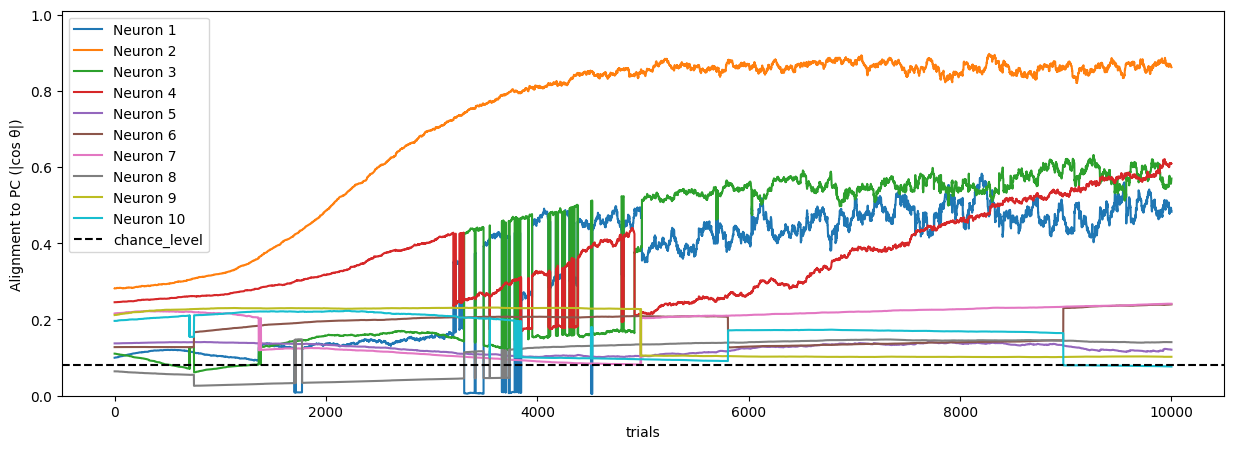

run  2
step    0 | order = [0 5 4 3 9 7 8 2 1 6] | best|corr|= [0.078 0.246 0.126 0.173 0.306 0.148 0.233 0.123 0.202 0.111]
step 1000 | order = [0 5 4 3 9 7 8 2 1 6] | best|corr|= [0.03  0.235 0.158 0.18  0.299 0.142 0.254 0.184 0.304 0.136]
step 2000 | order = [8 5 4 3 9 7 0 2 1 6] | best|corr|= [0.19  0.241 0.191 0.19  0.277 0.141 0.145 0.239 0.472 0.146]
step 3000 | order = [8 5 4 3 9 7 0 2 1 6] | best|corr|= [0.182 0.25  0.24  0.2   0.268 0.136 0.332 0.33  0.659 0.152]
step 4000 | order = [8 5 4 3 9 7 0 2 1 6] | best|corr|= [0.175 0.255 0.274 0.194 0.262 0.138 0.519 0.497 0.721 0.151]
step 5000 | order = [8 5 4 3 9 7 0 2 1 6] | best|corr|= [0.172 0.262 0.311 0.221 0.256 0.141 0.549 0.63  0.746 0.149]
step 6000 | order = [8 5 4 3 9 7 0 2 1 6] | best|corr|= [0.171 0.264 0.345 0.269 0.255 0.142 0.517 0.729 0.759 0.148]
step 7000 | order = [8 5 4 3 9 7 0 2 1 6] | best|corr|= [0.172 0.272 0.393 0.374 0.264 0.145 0.566 0.721 0.783 0.148]
step 8000 | order = [8 5 4 3 9 7 0 2 1 6] | best|

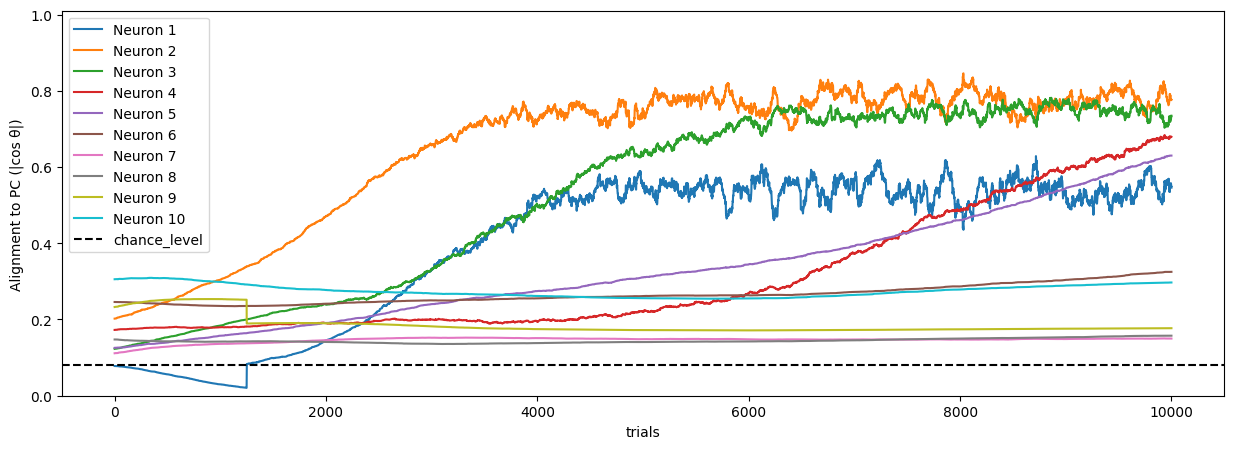

run  3
step    0 | order = [9 1 7 3 2 5 4 6 0 8] | best|corr|= [0.06  0.281 0.154 0.194 0.113 0.129 0.211 0.229 0.125 0.158]
step 1000 | order = [9 1 8 3 2 5 4 6 7 0] | best|corr|= [0.038 0.308 0.188 0.191 0.133 0.139 0.253 0.239 0.121 0.186]
step 2000 | order = [9 1 7 3 6 8 4 5 2 0] | best|corr|= [0.036 0.423 0.192 0.18  0.205 0.144 0.276 0.213 0.101 0.262]
step 3000 | order = [9 1 8 3 6 5 4 2 7 0] | best|corr|= [0.041 0.66  0.171 0.185 0.223 0.171 0.273 0.177 0.184 0.517]
step 4000 | order = [9 1 8 3 6 5 4 2 7 0] | best|corr|= [0.044 0.794 0.156 0.244 0.232 0.179 0.285 0.248 0.197 0.793]
step 5000 | order = [9 1 8 3 6 5 4 2 7 0] | best|corr|= [0.046 0.831 0.148 0.316 0.24  0.184 0.307 0.369 0.2   0.892]
step 6000 | order = [9 1 8 3 6 5 4 2 7 0] | best|corr|= [0.046 0.864 0.146 0.446 0.243 0.182 0.339 0.545 0.193 0.894]
step 7000 | order = [9 1 8 3 6 5 4 2 7 0] | best|corr|= [0.046 0.881 0.15  0.605 0.244 0.183 0.394 0.696 0.185 0.894]
step 8000 | order = [9 1 8 3 6 5 4 2 7 0] | best|

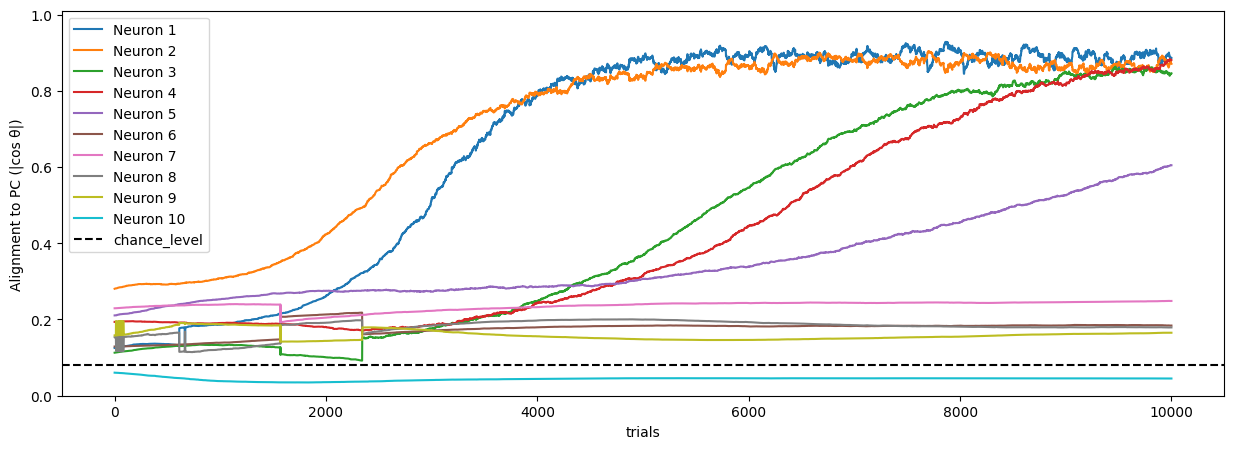

run  4
step    0 | order = [6 9 7 5 8 3 1 4 0 2] | best|corr|= [0.194 0.166 0.099 0.279 0.31  0.132 0.227 0.184 0.077 0.219]
step 1000 | order = [6 9 8 5 7 3 1 4 0 2] | best|corr|= [0.194 0.153 0.191 0.289 0.21  0.127 0.323 0.189 0.027 0.279]
step 2000 | order = [3 9 6 0 8 7 1 4 5 2] | best|corr|= [0.198 0.146 0.183 0.241 0.312 0.06  0.489 0.206 0.083 0.358]
step 3000 | order = [3 9 6 0 8 7 1 4 5 2] | best|corr|= [0.223 0.141 0.198 0.507 0.343 0.046 0.727 0.214 0.075 0.524]
step 4000 | order = [3 7 6 0 8 5 1 4 9 2] | best|corr|= [0.268 0.117 0.21  0.755 0.369 0.003 0.841 0.231 0.116 0.713]
step 5000 | order = [3 7 6 0 8 5 1 4 9 2] | best|corr|= [0.353 0.119 0.218 0.843 0.384 0.001 0.868 0.243 0.129 0.813]
step 6000 | order = [3 7 6 0 8 5 1 4 9 2] | best|corr|= [0.46  0.121 0.22  0.827 0.396 0.004 0.886 0.272 0.136 0.877]
step 7000 | order = [3 7 6 0 8 5 1 4 9 2] | best|corr|= [0.59  0.121 0.217 0.824 0.403 0.011 0.894 0.309 0.14  0.9  ]
step 8000 | order = [3 7 6 0 8 5 1 4 9 2] | best|

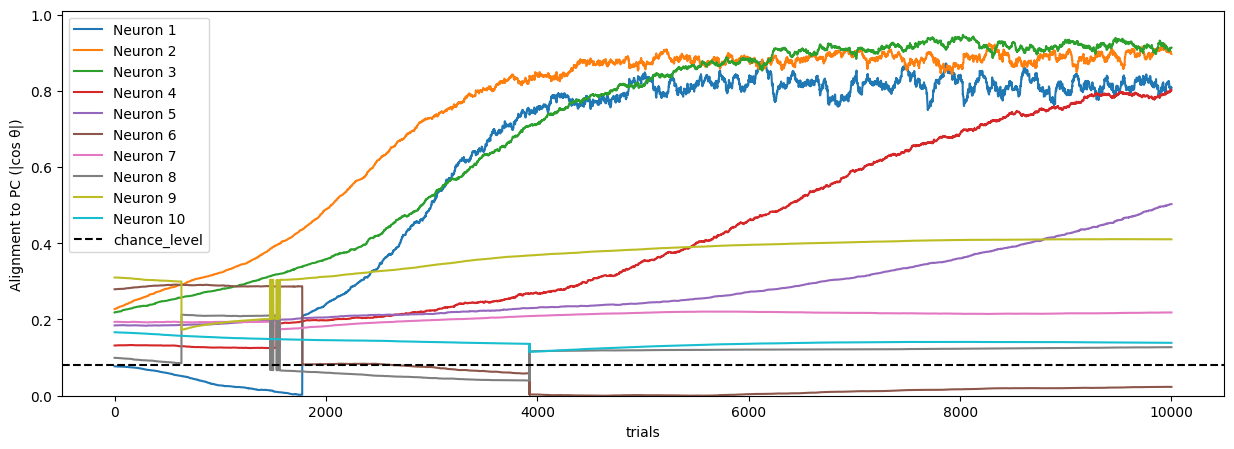

run  5
step    0 | order = [7 6 9 5 8 2 0 1 4 3] | best|corr|= [0.202 0.149 0.265 0.074 0.196 0.17  0.134 0.16  0.268 0.247]
step 1000 | order = [7 1 2 5 8 0 9 6 4 3] | best|corr|= [0.175 0.168 0.233 0.058 0.174 0.081 0.182 0.257 0.273 0.251]
step 2000 | order = [5 1 2 0 8 7 9 6 4 3] | best|corr|= [0.166 0.173 0.223 0.004 0.16  0.118 0.169 0.263 0.285 0.268]
step 3000 | order = [5 1 2 0 8 7 9 6 4 3] | best|corr|= [0.174 0.206 0.211 0.01  0.153 0.12  0.177 0.252 0.338 0.312]
step 4000 | order = [5 1 2 4 8 7 9 6 0 3] | best|corr|= [0.177 0.377 0.252 0.056 0.156 0.124 0.208 0.232 0.52  0.382]
step 5000 | order = [5 1 2 4 8 7 9 6 0 3] | best|corr|= [0.182 0.593 0.368 0.076 0.17  0.119 0.231 0.241 0.593 0.503]
step 6000 | order = [5 1 2 4 8 7 9 6 0 3] | best|corr|= [0.183 0.708 0.498 0.078 0.175 0.111 0.242 0.245 0.616 0.615]
step 7000 | order = [9 1 2 5 8 7 4 6 0 3] | best|corr|= [0.168 0.721 0.599 0.079 0.176 0.105 0.271 0.25  0.66  0.716]
step 8000 | order = [7 1 2 5 8 9 4 6 0 3] | best|

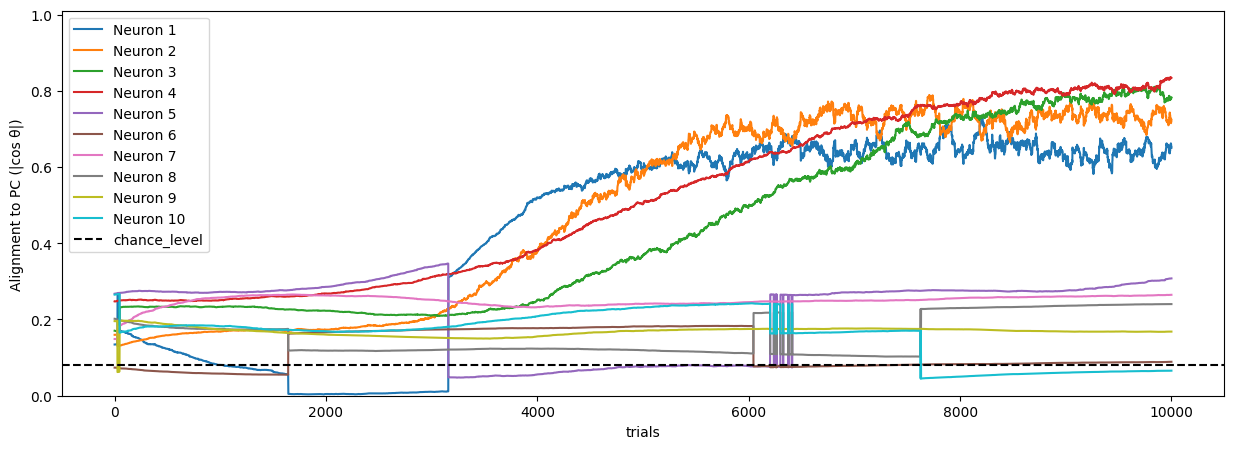

run  6
step    0 | order = [5 8 4 1 0 3 2 9 6 7] | best|corr|= [0.195 0.169 0.204 0.096 0.254 0.147 0.134 0.206 0.122 0.188]
step 1000 | order = [3 2 4 1 0 9 5 6 8 7] | best|corr|= [0.206 0.111 0.202 0.084 0.28  0.221 0.185 0.098 0.171 0.174]
step 2000 | order = [3 2 4 1 0 9 5 6 8 7] | best|corr|= [0.277 0.19  0.223 0.052 0.466 0.23  0.184 0.103 0.192 0.169]
step 3000 | order = [3 2 1 4 0 9 5 6 8 7] | best|corr|= [0.371 0.283 0.203 0.069 0.586 0.237 0.183 0.103 0.201 0.168]
step 4000 | order = [3 2 4 1 0 6 5 9 8 7] | best|corr|= [0.486 0.393 0.37  0.019 0.643 0.136 0.183 0.212 0.194 0.168]
step 5000 | order = [3 2 1 6 0 4 5 9 8 7] | best|corr|= [0.595 0.434 0.387 0.01  0.63  0.259 0.18  0.214 0.188 0.171]
step 6000 | order = [3 2 1 8 0 4 5 9 7 6] | best|corr|= [0.65  0.517 0.45  0.047 0.589 0.305 0.179 0.215 0.151 0.184]
step 7000 | order = [3 2 1 8 0 4 5 9 7 6] | best|corr|= [0.732 0.465 0.48  0.05  0.638 0.338 0.181 0.215 0.154 0.188]
step 8000 | order = [3 2 1 8 0 4 5 9 7 6] | best|

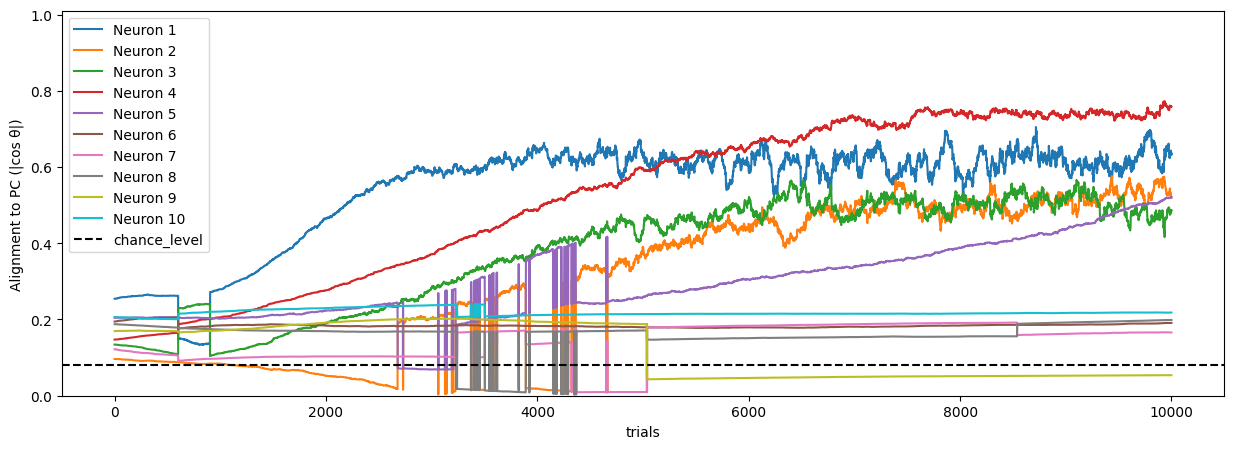

run  7
step    0 | order = [3 1 5 0 2 8 4 7 6 9] | best|corr|= [0.208 0.199 0.2   0.125 0.182 0.112 0.23  0.174 0.125 0.341]
step 1000 | order = [3 1 5 0 2 8 4 7 6 9] | best|corr|= [0.216 0.179 0.208 0.165 0.232 0.135 0.205 0.178 0.111 0.326]
step 2000 | order = [3 1 5 0 2 8 4 7 6 9] | best|corr|= [0.231 0.14  0.213 0.148 0.282 0.159 0.19  0.186 0.095 0.312]
step 3000 | order = [3 1 5 0 2 8 4 7 6 9] | best|corr|= [0.253 0.093 0.22  0.157 0.367 0.169 0.172 0.19  0.08  0.305]
step 4000 | order = [3 7 5 0 2 8 4 1 6 9] | best|corr|= [0.308 0.114 0.224 0.268 0.512 0.174 0.146 0.113 0.065 0.298]
step 5000 | order = [3 7 5 0 2 4 6 1 8 9] | best|corr|= [0.424 0.126 0.226 0.547 0.608 0.097 0.08  0.172 0.19  0.286]
step 6000 | order = [3 7 5 0 2 6 4 1 8 9] | best|corr|= [0.594 0.115 0.223 0.704 0.659 0.036 0.162 0.288 0.204 0.271]
step 7000 | order = [3 7 5 0 1 6 4 2 8 9] | best|corr|= [0.742 0.102 0.22  0.789 0.557 0.037 0.204 0.491 0.213 0.255]
step 8000 | order = [3 7 5 0 1 6 4 2 8 9] | best|

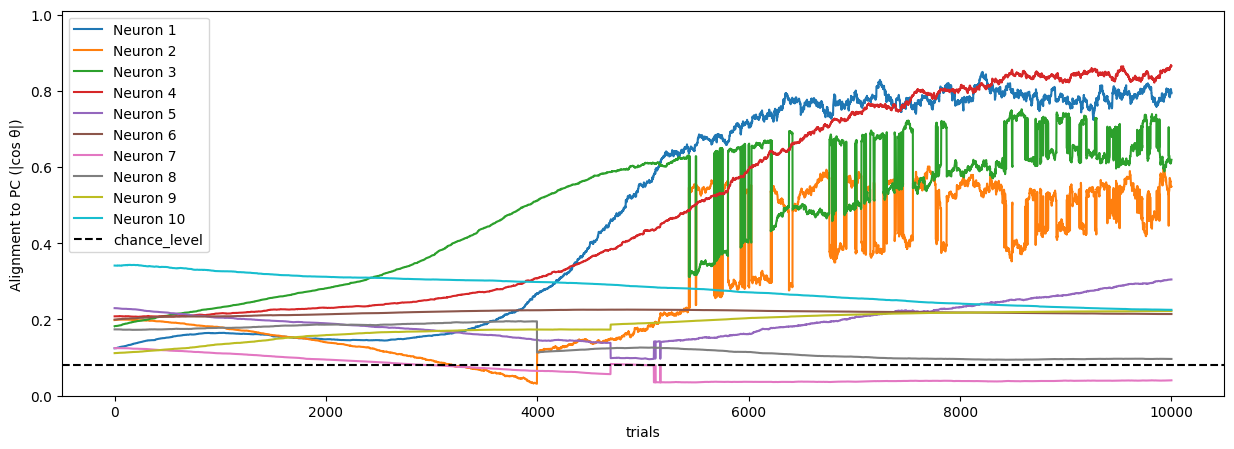

run  8
step    0 | order = [5 3 9 0 6 1 8 4 7 2] | best|corr|= [0.239 0.196 0.112 0.128 0.032 0.159 0.144 0.155 0.221 0.215]
step 1000 | order = [5 3 9 0 6 1 8 4 7 2] | best|corr|= [0.234 0.268 0.086 0.112 0.021 0.121 0.174 0.183 0.194 0.231]
step 2000 | order = [5 3 6 0 9 1 8 4 7 2] | best|corr|= [0.226 0.363 0.01  0.061 0.094 0.068 0.174 0.194 0.183 0.293]
step 3000 | order = [5 3 0 8 9 1 6 4 7 2] | best|corr|= [0.231 0.459 0.036 0.079 0.111 0.085 0.129 0.191 0.182 0.412]
step 4000 | order = [7 0 6 9 5 2 8 4 3 1] | best|corr|= [0.234 0.569 0.04  0.083 0.125 0.179 0.178 0.19  0.244 0.462]
step 5000 | order = [7 0 6 9 5 2 8 4 3 1] | best|corr|= [0.236 0.644 0.053 0.073 0.139 0.322 0.179 0.206 0.376 0.527]
step 6000 | order = [7 0 9 8 5 2 6 4 3 1] | best|corr|= [0.232 0.652 0.063 0.109 0.149 0.478 0.138 0.219 0.521 0.552]
step 7000 | order = [7 0 9 8 5 2 6 4 3 1] | best|corr|= [0.228 0.662 0.059 0.119 0.155 0.587 0.141 0.236 0.663 0.522]
step 8000 | order = [7 0 9 8 5 2 6 4 3 1] | best|

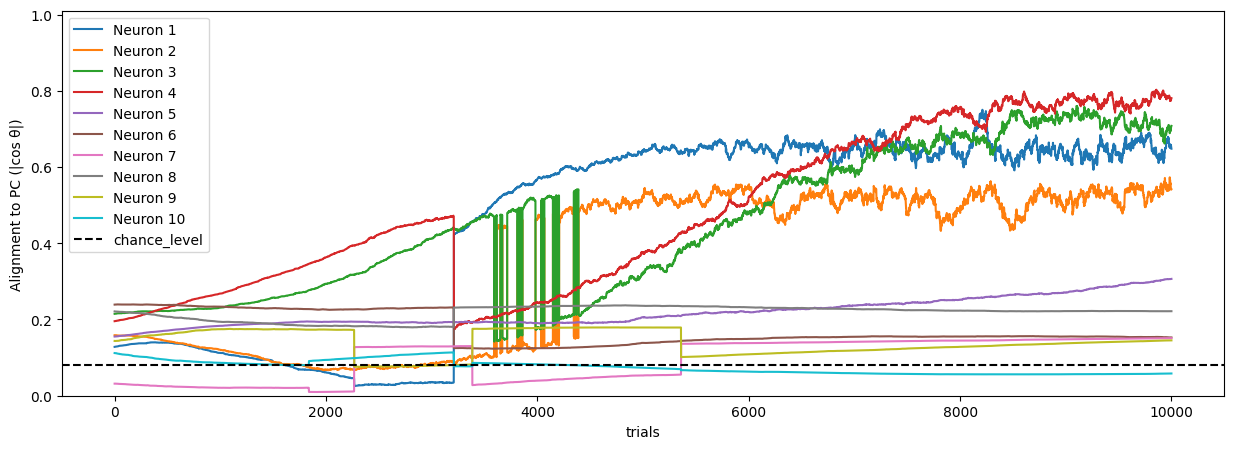

run  9
step    0 | order = [5 3 2 9 4 6 8 7 0 1] | best|corr|= [0.169 0.212 0.16  0.125 0.062 0.199 0.196 0.139 0.201 0.165]
step 1000 | order = [5 3 2 7 9 0 8 1 6 4] | best|corr|= [0.189 0.167 0.221 0.177 0.089 0.11  0.195 0.173 0.146 0.063]
step 2000 | order = [5 3 2 7 9 0 8 1 6 4] | best|corr|= [0.201 0.123 0.286 0.167 0.103 0.105 0.179 0.242 0.138 0.075]
step 3000 | order = [5 3 2 7 9 1 4 0 8 6] | best|corr|= [0.225 0.131 0.38  0.159 0.107 0.13  0.167 0.453 0.12  0.135]
step 4000 | order = [5 3 2 7 9 1 4 0 8 6] | best|corr|= [0.25  0.184 0.535 0.155 0.105 0.149 0.203 0.602 0.128 0.154]
step 5000 | order = [5 3 2 7 9 0 4 1 8 6] | best|corr|= [0.27  0.272 0.67  0.159 0.097 0.229 0.24  0.643 0.126 0.165]
step 6000 | order = [5 3 2 7 9 0 4 1 8 6] | best|corr|= [0.287 0.37  0.765 0.162 0.089 0.272 0.268 0.701 0.127 0.171]
step 7000 | order = [5 3 2 9 7 0 4 1 8 6] | best|corr|= [0.302 0.52  0.788 0.183 0.085 0.35  0.29  0.683 0.128 0.175]
step 8000 | order = [5 3 2 9 7 0 4 1 8 6] | best|

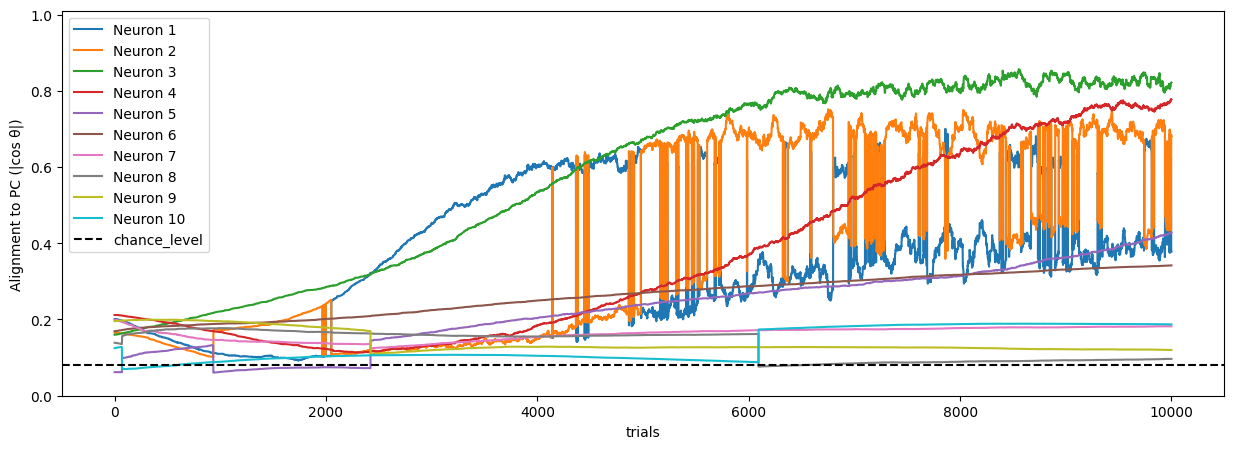

run 10
step    0 | order = [6 0 4 9 1 3 7 5 8 2] | best|corr|= [0.123 0.114 0.12  0.191 0.192 0.157 0.154 0.187 0.193 0.137]
step 1000 | order = [6 7 4 9 1 3 0 5 8 2] | best|corr|= [0.096 0.169 0.142 0.218 0.175 0.198 0.128 0.169 0.219 0.189]
step 2000 | order = [6 7 4 9 1 3 0 5 8 2] | best|corr|= [0.075 0.179 0.158 0.224 0.12  0.242 0.143 0.171 0.23  0.205]
step 3000 | order = [6 7 4 9 1 3 0 5 8 2] | best|corr|= [0.072 0.185 0.181 0.222 0.07  0.318 0.223 0.186 0.223 0.201]
step 4000 | order = [6 7 4 1 9 2 0 5 8 3] | best|corr|= [0.086 0.186 0.205 0.126 0.2   0.305 0.387 0.206 0.205 0.387]
step 5000 | order = [6 7 4 2 9 0 1 5 8 3] | best|corr|= [0.092 0.184 0.207 0.16  0.21  0.361 0.495 0.218 0.192 0.533]
step 6000 | order = [6 7 4 2 9 0 1 5 8 3] | best|corr|= [0.098 0.185 0.203 0.296 0.204 0.38  0.572 0.228 0.178 0.646]
step 7000 | order = [6 7 4 1 9 2 0 5 8 3] | best|corr|= [0.108 0.185 0.192 0.468 0.184 0.409 0.57  0.235 0.165 0.739]
step 8000 | order = [6 7 4 1 9 2 0 5 8 3] | best|

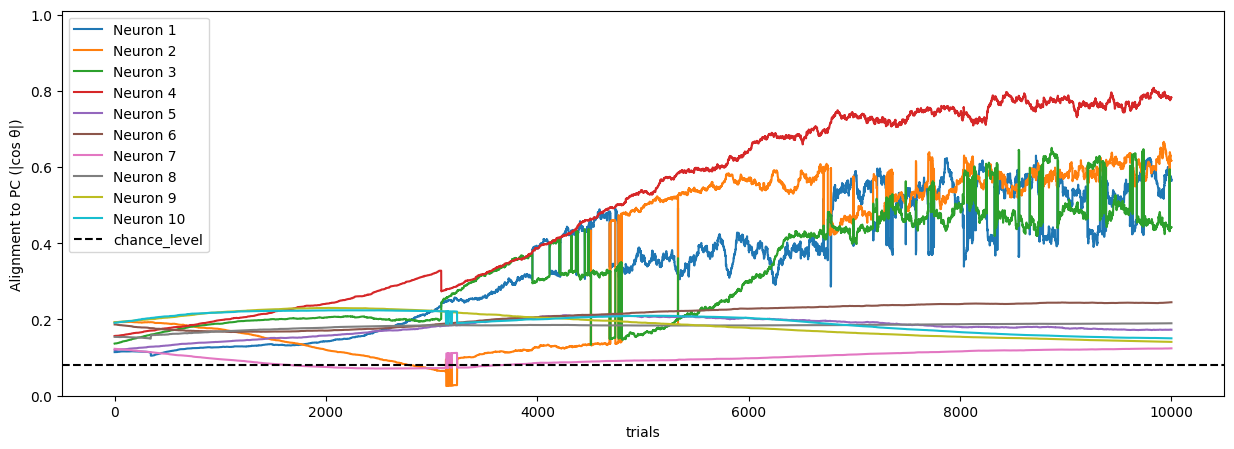

<Figure size 640x480 with 0 Axes>

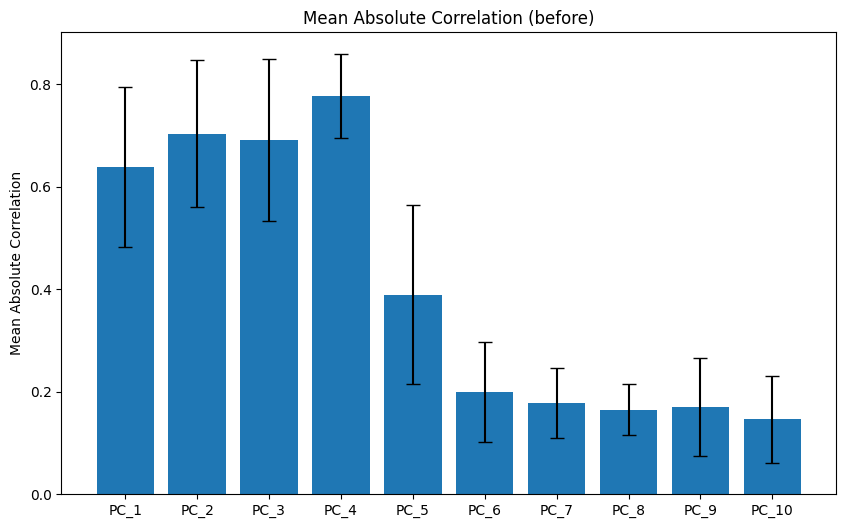

In [19]:
model_paras = {
    "input_size": N,
    "output_size": m,
    "eta_w": 5e-5,
    "eta_v": 5e-4
}

model = FoldiakPCA(**model_paras)

training_testing(model, samples_10d, m, runs=10)